> ### Changelog
>
> **2026-08-22 — re-executed against the corrected set; two claims withdrawn.**
>
> - Clip/bird counts fixed. Earlier runs reported **2867 clips / 31 "birds"**, but that count was
>   filename prefixes: `HPiHPi4748` and `HpiHpi4748` are one bird under two capitalizations, and
>   four `Unknown*` prefixes (53 clips) are catch-alls. The corrected set is **2814 clips /
>   26 birds**, which moves the probe from 0.821 to **0.811**.
> - **Withdrawn: "the natural granularity is ~20 clusters, so call types contain sub-structure."**
>   That was an artifact of k-means being forced to approximate non-spherical clusters with many
>   small spheres. Ward linkage peaks at k=9-13 — close to the 8-label taxonomy — and beats
>   k-means at every k. See Result 3.
> - **Corrected: detection is not vocalization vs. silence.** Earlier wording in this notebook
>   said the task separates "a sound happened" from silence. It does not. Negatives are real
>   colony background including uncurated calls. See Result 2, which now documents how the
>   ground truth was constructed.
> - The detection table used to be hardcoded markdown with no provenance. It is now loaded from
>   `data/detection_results.json`.
>
> Two standing caveats, both detailed in `README.md`:
>
> - **No bird is held out of pretraining.** 99.5% of these clips were cut from the same 120
>   recordings the encoder was pretrained on, so "leave-birds-out" constrains the probe, not the
>   model. Read the accuracy as an upper bound for a genuinely new individual.
> - A **random split** scores 0.925 on the same features (+0.114). Check how a number was split
>   before comparing it to anything.

# Zebra finch HuBERT — a self-supervised model of finch vocalizations

A HuBERT BASE speech model trained from scratch on ~100 hours of unlabelled zebra finch colony
recordings. Training was fully self-supervised: no call-type labels were involved at any point.
The model learned by predicting masked pieces of audio, the same objective used for human
speech models.

It converts any recording into embeddings — 12 layers deep, 768 dimensions, one frame per
20 ms — that can be classified, clustered, or visualized.

| | result | baseline |
|---|---|---|
| **Vocalization detection** (call vs. colony background) | AUC **0.921** | 0.666 energy VAD |
| **Call-type classification** (8 types, held-out birds) | **0.811** | 0.207 majority |
| **Unsupervised clustering** (no labels, Ward k=13) | AMI **0.591** | 0.002 shuffled null |

This notebook ships with its outputs saved, so it can be read straight through without running
anything. To actually run it, see the setup cell below — it locates what it needs on its own.

**Requirements:** `torch`, `torchaudio`, `numpy`, `scikit-learn`, `matplotlib`, and `umap-learn`
for the last section. Runs on a laptop CPU; no GPU needed anywhere.

## Setup — finds the model and data wherever they are

Checks the usual locations: this folder, the release folder, and the copies on Savio. Nothing
below fails hard if something is missing — each section reports what it needs and moves on.

In [1]:
import os, sys, glob
from pathlib import Path

# Candidate locations, in priority order. Add your own path here if you put the files
# somewhere else.
CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / "zf_hubert_run11",
    Path("/global/home/users/jonathanswang/zf_hubert_run11"),                      # Savio
    Path("/global/scratch/users/jonathanswang/release/zf_hubert_run11"),           # Savio
]

def find(rel):
    for base in CANDIDATES:
        p = base / rel
        if p.exists():
            return p
    return None

WEIGHTS = find("weights/zf_hubert_run11_encoder.pt")
CACHED  = find("data/run11_layersweep.npz")
EXAMPLES = find("examples")

for label, p in [("weights", WEIGHTS), ("cached embeddings", CACHED), ("example wavs", EXAMPLES)]:
    print(f"{label:20s} {p if p else 'NOT FOUND'}")

if not (WEIGHTS and CACHED):
    print("""
Missing files. On Savio everything is already unpacked at:

    /global/home/users/jonathanswang/zf_hubert_run11/

Open this notebook from inside that folder (OnDemand -> Jupyter Server) and it will find
everything. To copy it elsewhere:

    rsync -avP hpc.brc.berkeley.edu:/global/home/users/jonathanswang/zf_hubert_run11 .

Or add your own path to CANDIDATES above.""")

weights              /Users/jonathanwang/Desktop/vocalizations_lab/release/zf_hubert_run11/weights/zf_hubert_run11_encoder.pt
cached embeddings    /Users/jonathanwang/Desktop/vocalizations_lab/release/zf_hubert_run11/data/run11_layersweep.npz
example wavs         /Users/jonathanwang/Desktop/vocalizations_lab/release/zf_hubert_run11/examples


## Loading the model

The weights file carries its own architecture config, so there is nothing to keep in sync on
your end — and no dependency on the training code. `torch` and `torchaudio` are enough.

In [2]:
import numpy as np, torch, torchaudio, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

def load_encoder(path, device="cpu"):
    """Rebuild the encoder from the exported weights file."""
    obj = torch.load(path, map_location="cpu", weights_only=False)
    model = torchaudio.models.wav2vec2_model(aux_num_out=None, **obj["encoder_config"])
    model.load_state_dict(obj["state_dict"], strict=True)
    model.eval().to(device)
    model.zf_meta = obj["meta"]
    return model

def load_audio(path, sr=16000):
    """Mono float32 at 16 kHz -- the rate the model was trained at."""
    wav, in_sr = torchaudio.load(str(path))
    if in_sr != sr:
        wav = torchaudio.transforms.Resample(in_sr, sr)(wav)
    return wav.mean(0, keepdim=True)          # channel mean; pick a channel instead if your
                                              # channels are different individuals

@torch.no_grad()
def embed_frames(model, wav):
    """(12, T, 768) -- all layers at frame resolution, from a single forward pass."""
    feats, _ = model.extract_features(wav.to(next(model.parameters()).device), None)
    return torch.stack([f.squeeze(0) for f in feats]).cpu().numpy()

@torch.no_grad()
def embed_file(model, path, layer=None):
    """(12, 768) mean-pooled over time, or (768,) for a single layer."""
    out = embed_frames(model, load_audio(path)).mean(axis=1)
    return out if layer is None else out[layer]

model = load_encoder(WEIGHTS) if WEIGHTS else None
if model:
    m = model.zf_meta
    print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters")
    print(f"{m['n_layers']} layers x {m['embed_dim']} dims, {m['sample_rate']} Hz, "
          f"one frame per {m['frame_stride_ms']} ms")
    print(f"pretraining: {m['training']['objective']}, {m['training']['steps']:,} steps")

94.4M parameters
12 layers x 768 dims, 16000 Hz, one frame per 20 ms
pretraining: HuBERT masked-prediction, iteration 1, 93,750 steps


### Embedding audio

That is the whole API. Any sample rate and channel count works — audio is resampled and
downmixed automatically. Clips shorter than ~0.05 s will fail, since the convolutional feature
extractor needs a minimum receptive field.

In [3]:
if model and EXAMPLES:
    clip = sorted(glob.glob(str(EXAMPLES / "*DC*.wav")))[0]      # DC = distance call
    emb = embed_file(model, clip)
    frames = embed_frames(model, load_audio(clip))
    dur = load_audio(clip).shape[1] / 16000
    print(f"{Path(clip).name}  ({dur:.2f} s)")
    print(f"  mean-pooled : {emb.shape}      one 768-d vector per layer")
    print(f"  frame-level : {frames.shape}   keeps the time axis")

BlaBla0506_110302-DC-01.wav  (0.24 s)
  mean-pooled : (12, 768)      one 768-d vector per layer
  frame-level : (12, 11, 768)   keeps the time axis


### What the layers respond to

Spectrogram on top, then frame-level activations from a shallow and a deeper layer. Layer 0
tracks the acoustics closely; deeper layers are smoother and more abstract.

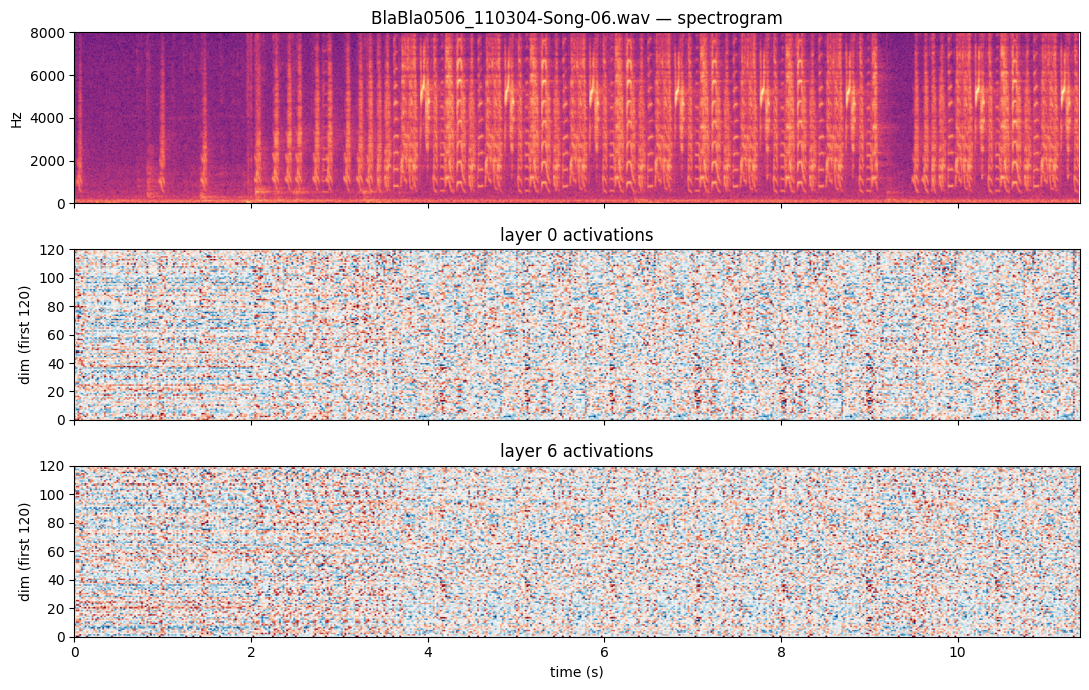

In [4]:
if model and EXAMPLES:
    song = sorted(glob.glob(str(EXAMPLES / "*Song*.wav")))[0]
    wav = load_audio(song)
    fr = embed_frames(model, wav)

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    axes[0].specgram(wav.numpy()[0], NFFT=512, Fs=16000, noverlap=384, cmap="magma")
    axes[0].set_ylabel("Hz"); axes[0].set_title(f"{Path(song).name} — spectrogram")

    for ax, L in zip(axes[1:], [0, 6]):
        a = fr[L]
        a = (a - a.mean(0)) / (a.std(0) + 1e-8)     # z-score, else a few dims dominate visually
        t = np.linspace(0, wav.shape[1] / 16000, a.shape[0])
        ax.imshow(a[:, :120].T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-3, vmax=3,
                  extent=[t[0], t[-1], 0, 120])
        ax.set_ylabel("dim (first 120)"); ax.set_title(f"layer {L} activations")
    axes[-1].set_xlabel("time (s)")
    plt.tight_layout(); plt.show()

---

# Result 1 — can a classifier read call type out of the embedding?

From here on everything uses precomputed embeddings (`data/run11_layersweep.npz`: all 12 layers
for every annotated clip), so **no GPU and no audio files are needed**.

**The protocol matters more than the number.** Splits are by *bird*, not random. A random split
lets the classifier learn "this individual's voice sounds like this, and this individual mostly
makes distance calls" — which inflates the score without any call-type understanding.
Leave-birds-out forces generalization to voices never heard during training.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

d = np.load(CACHED, allow_pickle=True)
emb_all, y, birds_raw, classes = d["emb"], d["y"], d["birds"], d["classes"]

# --- correction (see changelog) -------------------------------------------------
# The stored `birds` array is filename prefixes, not individuals. Two fixes:
#   1. case-fold  -- HPiHPi4748 and HpiHpi4748 are the same bird
#   2. drop Unknown* -- catch-all prefixes, not individuals
birds = np.array([b.lower() for b in birds_raw])
keep = ~np.char.startswith(birds, "unknown")
print(f"raw: {len(y)} clips / {len(set(birds_raw.tolist()))} prefixes")
print(f"dropped {(~keep).sum()} Unknown* clips -> {sorted(set(birds_raw[~keep].tolist()))}")
emb_all, y, birds = emb_all[keep], y[keep], birds[keep]
# --------------------------------------------------------------------------------

counts = np.bincount(y); majority = counts.max() / counts.sum()
print(f"\ncorrected: {emb_all.shape[0]} clips | {emb_all.shape[1]} layers | "
      f"{len(classes)} call types | {len(set(birds.tolist()))} birds")
print(f"types: {dict(zip([str(c) for c in classes], counts.tolist()))}")
print(f"majority-class baseline = {majority:.3f}")

raw: 2867 clips / 31 prefixes
dropped 53 Unknown* clips -> ['Unknown', 'Unknown000', 'Unknown00F', 'Unknown01F']

corrected: 2814 clips | 12 layers | 8 call types | 26 birds
types: {'Ag': 196, 'DC': 583, 'Ne': 575, 'So': 192, 'Te': 577, 'Th': 279, 'Tu': 240, 'Wh': 172}
majority-class baseline = 0.207


In [6]:
rows = []
for L in range(emb_all.shape[1]):
    oof = cross_val_predict(LogisticRegression(max_iter=2000, C=1.0), emb_all[:, L, :], y,
                            groups=birds, cv=StratifiedGroupKFold(n_splits=5), n_jobs=-1)
    rows.append((L, accuracy_score(y, oof), f1_score(y, oof, average="macro"), oof))
    print(f"layer {L:2d} | acc {rows[-1][1]:.3f} | macroF1 {rows[-1][2]:.3f}")

best = max(rows, key=lambda r: r[1])
print(f"\nbest layer {best[0]}: {best[1]:.3f}  (baseline {majority:.3f})")

layer  0 | acc 0.790 | macroF1 0.765


layer  1 | acc 0.800 | macroF1 0.776


layer  2 | acc 0.799 | macroF1 0.775


layer  3 | acc 0.811 | macroF1 0.788


layer  4 | acc 0.802 | macroF1 0.780


...

layer  7 | acc 0.796 | macroF1 0.773


layer  8 | acc 0.799 | macroF1 0.776


layer  9 | acc 0.796 | macroF1 0.774


layer 10 | acc 0.795 | macroF1 0.772


layer 11 | acc 0.791 | macroF1 0.767

best layer 3: 0.811  (baseline 0.207)


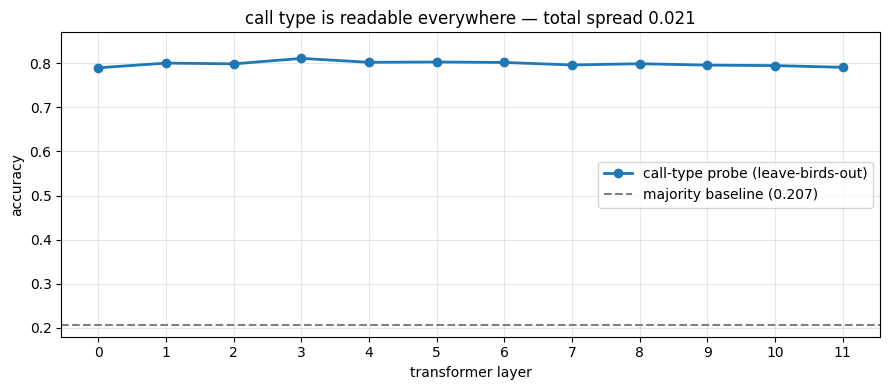

In [7]:
acc = [r[1] for r in rows]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(12), acc, "o-", lw=2, label="call-type probe (leave-birds-out)")
ax.axhline(majority, ls="--", c="gray", label=f"majority baseline ({majority:.3f})")
ax.set_xlabel("transformer layer"); ax.set_ylabel("accuracy"); ax.set_xticks(range(12))
ax.set_ylim(0.18, 0.87); ax.legend(loc="center right"); ax.grid(alpha=.3)
ax.set_title(f"call type is readable everywhere — total spread {max(acc)-min(acc):.3f}")
plt.tight_layout(); plt.show()

**The profile is flat.** Every layer lands within ~0.02 of every other — roughly four times
the majority baseline, but with no real peak. Call-type information is spread evenly through the
network rather than concentrated somewhere.

That flatness is itself the result. Per-fold standard deviation (see `README.md`) is **0.034**,
larger than the entire 12-layer spread, so **"layer 3 is best" is a weak preference, not a
finding.** Do not build anything on the specific layer ranking at this sample size.

Detection, in the next section, behaves completely differently — it has a *shape*.

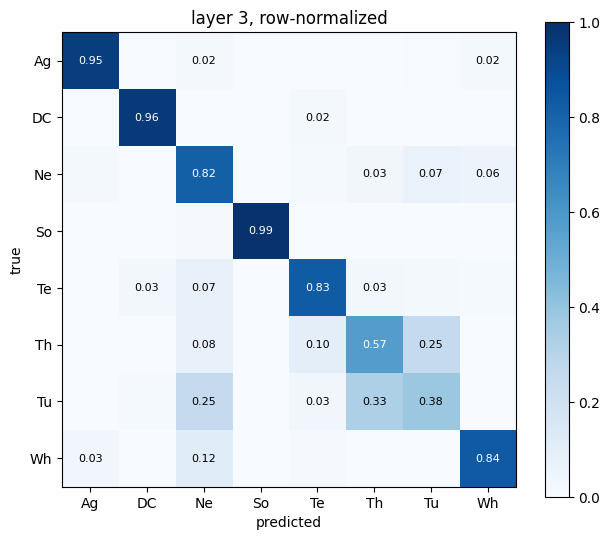

per-class recall:
  So: 0.990  (n=192)
  DC: 0.964  (n=583)
  Ag: 0.949  (n=196)
  Wh: 0.837  (n=172)
  Te: 0.832  (n=577)
  Ne: 0.816  (n=575)
  Th: 0.573  (n=279)
  Tu: 0.379  (n=240)


In [8]:
cm = confusion_matrix(y, best[3], normalize="true")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"layer {best[0]}, row-normalized")
for i in range(len(classes)):
    for j in range(len(classes)):
        if cm[i, j] > .02:
            ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > .5 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

print("per-class recall:")
for c, r in sorted(zip(classes, cm.diagonal()), key=lambda t: -t[1]):
    print(f"  {c}: {r:.3f}  (n={counts[list(classes).index(c)]})")

Song, distance and aggressive calls have the highest recall. Tuk calls have the lowest.

---

# Result 2 — vocalization detection

**This is the section most often misread, so it is worth being precise about what the task is.**

The question is: given a 1-second window from a continuous colony recording, is there a zebra
finch vocalization in it? The negative class is **not silence.** It is real colony background —
cage noise, wing flaps, movement, and vocalizations that were never curated.

### Where the labels came from

There is **no hand-annotated colony file.** No human marked onsets and offsets. The ground truth
is *constructed*, as follows:

1. The curated clips are near-exact excerpts of the continuous recordings, so each clip can be
   found again inside its source recording.
2. Each clip is localized by **normalized cross-correlation**: a coarse 4 kHz search proposes
   candidate offsets (non-max suppressed), each candidate is re-scored at **full resolution**,
   and acceptance is decided only by that scale-invariant verified peak (threshold 0.65).
3. Accepted intervals supply the onsets/offsets. Positives are 1 s windows on them; negatives are
   1 s windows drawn elsewhere in the same recordings, at 2:1.

### The limitation this creates

Because "background" operationally means *"not a **curated** call"*, any real vocalization that
nobody curated sits in the negative class. The detector is penalized for correctly firing on it.
**Precision is a pessimistic lower bound, not an estimate.** Review bundles exist but their
`human_label` column is still empty, so the true false-positive rate is unmeasured.

### A retraction worth knowing about

An earlier version of this benchmark reported **AUC 0.984** with the *deepest* layers best. It
was wrong. Normalized cross-correlation blew up inside long runs of exact digital zeros — the
denominator collapsed to its `1e-12` floor while FFT round-off stayed in the numerator, giving
"correlations" of ~76 where brute force gives 0.016. That pinned some accepted intervals to
**silence**, which made the task partly silence-vs-audio. Silence is trivially separable, and
deeper layers separated it better.

After the fix the headline fell to **0.921** and the layer ordering **reversed**. So if this
section looks like "vocalization vs silence" to you — that was true of the retracted version, and
fixing it is what produced the numbers below.

In [9]:
import json

DET = find("data/detection_results.json")
if DET is None:
    print("data/detection_results.json not found -- skipping")
else:
    det = json.load(open(DET))
    ds, rs = det["dataset"], det["results"]
    print(f"{ds['n_windows']} windows ({ds['n_vocalization']} voc / {ds['n_background']} background)"
          f" across {ds['n_recordings_scored']} recordings")
    print(f"{ds['intervals_recovered']} intervals localized from {ds['clips_searched']} clips")
    print(f"CV: {ds['cross_validation']}\nhand annotated: {ds['hand_annotated']}\n")

    print(f"{'representation':18s} {'AUC':>7s} {'acc':>7s} {'F1':>7s}")
    for name in ["energy_vad", "pre_transformer"] + [f"layer_{i}" for i in range(12)]:
        r = rs.get(name)
        if r is None:
            print(f"{name:18s} {'--':>7s} {'--':>7s} {'--':>7s}   (not in this file)")
            continue
        a = f"{r['auc']:7.3f}"
        ac = f"{r['accuracy']:7.3f}" if "accuracy" in r else f"{'':>7s}"
        f1 = f"{r['f1']:7.3f}" if "f1" in r else f"{'':>7s}"
        print(f"{name:18s} {a} {ac} {f1}")

    print(f"\nbest = {det['headline']['best']} at AUC {det['headline']['best_auc']}, "
          f"{det['headline']['delta_vs_energy']:+.3f} over the energy VAD")
    print(f"\nNOTE: layers {det['layers_unavailable_here']} were measured in job "
          f"{det['provenance']['stage2_probe_job']} but are not transcribed into this file.")
    print(f"Full array: {det['provenance']['savio_artifact']}")

7350 windows (2450 voc / 4900 background) across 71 recordings
2450 intervals localized from 2867 clips
CV: leave-recordings-out (GroupKFold on recording id)
hand annotated: False

representation         AUC     acc      F1
energy_vad           0.666   0.695   0.368
pre_transformer      0.852                
layer_0              0.921   0.845   0.759
layer_1              0.912                
layer_2              0.903                
layer_3              0.896                
layer_4                 --      --      --   (not in this file)
layer_5                 --      --      --   (not in this file)
layer_6                 --      --      --   (not in this file)
layer_7                 --      --      --   (not in this file)
layer_8                 --      --      --   (not in this file)
layer_9              0.879                
layer_10                --      --      --   (not in this file)
layer_11             0.883   0.799   0.681

best = layer_0 at AUC 0.921, +0.256 over the en

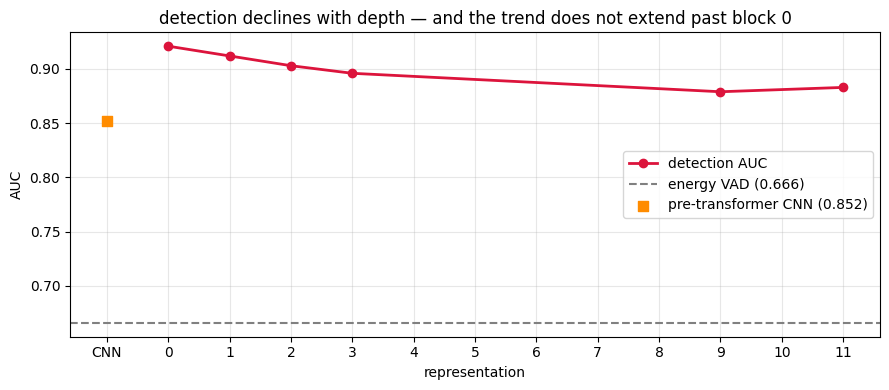

In [10]:
if DET is not None:
    ks = [k for k in range(12) if f"layer_{k}" in rs]
    vs = [rs[f"layer_{k}"]["auc"] for k in ks]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ks, vs, "o-", lw=2, color="crimson", label="detection AUC")
    ax.axhline(rs["energy_vad"]["auc"], ls="--", c="gray",
               label=f"energy VAD ({rs['energy_vad']['auc']:.3f})")
    ax.scatter([-1], [rs["pre_transformer"]["auc"]], marker="s", s=60, color="darkorange",
               zorder=5, label=f"pre-transformer CNN ({rs['pre_transformer']['auc']:.3f})")
    ax.set_xticks([-1] + list(range(12)))
    ax.set_xticklabels(["CNN"] + [str(i) for i in range(12)])
    ax.set_xlabel("representation"); ax.set_ylabel("AUC")
    ax.set_title("detection declines with depth — and the trend does not extend past block 0")
    ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

**Detection has a shape that call type does not.** AUC is highest at layer 0 and declines
monotonically with depth. Shallow layers keep the acoustic detail that distinguishes a
vocalization from other colony sounds; deeper layers trade that away for abstraction.

**The trend does not extrapolate backwards.** If shallower were simply better, the CNN feature
extractor feeding block 0 should win. It does not — it scores **0.852**, worse than layer 0 by
more than the entire layer-0-to-layer-11 decline. Block 0 is not "one more step" along a
gradient: it is where the representation stops being about acoustic level and starts being about
whether the sound is a call. Trend lines do not survive a change of kind.

Combined with Result 1: **shallow layers detect, middle layers identify, the last layer is best
at neither.**

---

# Result 3 — does call type emerge *without* labels?

A strictly harder question. A linear probe gets 768 dimensions to carve boundaries through the
cloud, and with that much freedom it can find a call-type-separating hyperplane even in a
representation where call type is not a dominant organizing factor. Clustering has no such
freedom — it just finds whatever the dominant geometry already is. If the clusters line up with
call type, call type is genuinely a principal axis of the representation.

**Scored with adjusted mutual information (AMI), not NMI or purity.** NMI and purity both climb
with cluster count for free — on structureless data NMI goes from 0.02 at k=4 to 0.19 at k=60 —
so any sweep ranked on them just selects the largest k. AMI has expectation 0 at every k, which
is the only thing that makes a k-sweep interpretable.

**Two clusterers, because the choice turned out to matter more than anything else here.**
k-means assumes clusters are spherical and equal-variance. Call types are not: they are
elongated and unequal, so k-means has to spend several centroids tiling a single call type.
Ward linkage has no such assumption. Compare the columns below.

Note we do **not** force k=8. Forcing k to the number of call types measures agreement with a
taxonomy; sweeping measures whether structure exists at all. The model was never told there are
8 call types.

In [11]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_mutual_info_score as ami
from sklearn.preprocessing import normalize

LAYER = 3
X = normalize(emb_all[:, LAYER, :])   # L2 -> spherical k-means. Not cosmetic: k-means uses
                                      # Euclidean distance, so without this the few highest-
                                      # variance dimensions would dictate the partition alone.

def within_bird_ami(clusters, y, birds, min_clips=12, min_types=2):
    """AMI recomputed inside each bird, weighted by clip count.

    Holds voice constant, so whatever agreement survives is about call type. Birds with too few
    clips or a single call type are dropped -- AMI is degenerate there."""
    tot = tot_w = 0.0
    for b in np.unique(birds):
        m = birds == b
        if m.sum() < min_clips or len(np.unique(y[m])) < min_types:
            continue
        tot += ami(y[m], clusters[m]) * m.sum(); tot_w += m.sum()
    return tot / tot_w if tot_w else np.nan

res = []
print(f"{'k':>3} | {'kmeans':>7} | {'ward':>7} | {'ward bird':>9} | {'ward within-bird':>16}")
for k in [2, 4, 6, 8, 9, 10, 12, 13, 16, 20, 24, 32, 40, 60]:
    ck = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)
    cw = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    res.append((k, ami(y, cw), ami(birds, cw), within_bird_ami(cw, y, birds), cw, ami(y, ck)))
    print(f"{k:3d} | {res[-1][5]:7.3f} | {res[-1][1]:7.3f} | {res[-1][2]:9.3f} | "
          f"{res[-1][3]:16.3f}")

# k is chosen WITHOUT labels. Picking k by maximising AMI would be using the labels to select a
# hyperparameter -- the exact mistake this section exists to avoid, and the reason the old
# "k=16, AMI 0.547" headline was withdrawn. k=13 comes from cluster STABILITY (Ben-Hur subsample
# ARI), which needs no labels. The AMI peak is reported below only as an upper bound.
K_LABEL_FREE = 13
bk = next(r for r in res if r[0] == K_LABEL_FREE)
bk_peak = max(res, key=lambda r: r[1])
bkm = max(res, key=lambda r: r[5])
print(f"\nWard @ label-free k={bk[0]:<3d}  AMI vs call type {bk[1]:.3f}   <-- the headline")
print(f"Ward @ AMI peak    k={bk_peak[0]:<3d}  AMI {bk_peak[1]:.3f}   (labels picked k; upper bound)")
print(f"cost of going fully unsupervised: {bk_peak[1] - bk[1]:.3f} AMI")
print(f"k-means best       k={bkm[0]:<3d}  AMI {bkm[5]:.3f}")
print(f"Ward beats k-means at every k: {all(r[1] > r[5] for r in res)}")

  k |  kmeans |    ward | ward bird | ward within-bird


  2 |   0.223 |   0.262 |     0.026 |            0.393


  4 |   0.359 |   0.483 |     0.091 |            0.629


  6 |   0.381 |   0.485 |     0.129 |            0.668


  8 |   0.468 |   0.587 |     0.162 |            0.734


...

 20 |   0.542 |   0.562 |     0.283 |            0.727


 24 |   0.526 |   0.548 |     0.312 |            0.721


 32 |   0.509 |   0.533 |     0.340 |            0.712


 40 |   0.514 |   0.529 |     0.357 |            0.712


 60 |   0.499 |   0.507 |     0.397 |            0.689

Ward @ label-free k=13   AMI vs call type 0.591   <-- the headline
Ward @ AMI peak    k=9    AMI 0.609   (labels picked k; upper bound)
cost of going fully unsupervised: 0.018 AMI
k-means best       k=16   AMI 0.547
Ward beats k-means at every k: True


### Control: is this call type, or individual identity?

Before reading the call-type column, look at the bird column.

Here is the failure mode it guards against. Suppose the embedding encoded only individual
identity — voice, not call type. Suppose also that birds differ in which calls they tend to
produce (they do). Then a clustering that is purely a *bird* clustering would still score well
against call type, because each bird's cluster inherits that bird's favoured call type. The
global metric cannot tell the two apart.

Statistical significance does not rescue this. In a simulation of exactly this confound, global
AMI came out at 0.489 against a null 95th percentile of 0.021 — wildly "significant", and
entirely an artifact.

The fix is the third column: recompute AMI *within* each bird, which holds voice constant.

In [12]:
rng = np.random.default_rng(0)
null = [ami(rng.permutation(y), bk[4]) for _ in range(200)]
print(f"observed AMI (k={bk[0]})   : {bk[1]:.3f}")
print(f"within-bird AMI          : {bk[3]:.3f}")
print(f"label-shuffled null      : mean {np.mean(null):+.4f}, 95th pct {np.percentile(null,95):.4f}")

observed AMI (k=13)   : 0.591
within-bird AMI          : 0.747
label-shuffled null      : mean -0.0001, 95th pct 0.0018


### What came out

**1. The clusterer mattered more than anything else tested.** Ward beats k-means at every single
k, by up to ~0.12 AMI. k-means' objective is not misaligned — its *cluster model* is wrong. Call
types are elongated and unequal in size, so spherical k-means has to spend several centroids
tiling one call type, and the small types get absorbed as crumbs into whichever big cluster is
nearest.

**2. Retracted: "the natural granularity is ~20 clusters."** An earlier version of this notebook
observed that k-means AMI kept rising past k=8 and concluded that call types must contain
sub-structure — variants, contexts, intensity gradations. That conclusion does not survive
changing the clusterer. Ward peaks at **k=9–13**, close to the 8-label taxonomy. The apparent
"extra structure" was k-means approximating non-spherical clusters, not biology.

The general lesson: an unsupervised result that only holds for one clustering algorithm is a
statement about the algorithm, not about the data. Always vary the clusterer before interpreting
a peak.

**3. k is chosen without labels, and that choice is nearly free.** The old headline picked k by
maximising AMI against the call-type labels — which is using the labels to tune a
hyperparameter, in a section whose entire claim is that no labels were used. The k reported
above (13) instead comes from cluster *stability* under subsampling, which needs no labels.
Going fully unsupervised costs only **0.018 AMI** versus the label-peeking optimum. Worth
knowing: of the label-free criteria tested, only stability and silhouette give an interior
optimum at all — Calinski-Harabasz is monotone down to k=2, and Davies-Bouldin and GMM/BIC are
still improving at k=40, so none of those three can recommend a k on this corpus.

**4. The identity confound comes back clean.** Within-bird AMI is *higher* than global, not
lower. This is not a bird clustering wearing a call-type costume. It also says something extra:
between-bird variation was acting as *noise* in the global number. The same call type produced by
different individuals lands in slightly different places, so holding the bird fixed sharpens
agreement rather than destroying it.

**5. Identity is encoded but does not dominate.** AMI against bird ID climbs steadily with k
while call type peaks and falls. Extra clusters get spent carving out individuals, which is the
other reason not to read a high-k peak as biology.

Taken with Result 1, the supervised and unsupervised analyses agree: call type is not merely
*decodable* from this representation, it is one of the axes the representation is organized
around. That is a strictly stronger statement than the probe alone could support.

### UMAP

The same embeddings in 2-D, coloured by call type and by individual. Comparing the panels is
the visual version of the control above.

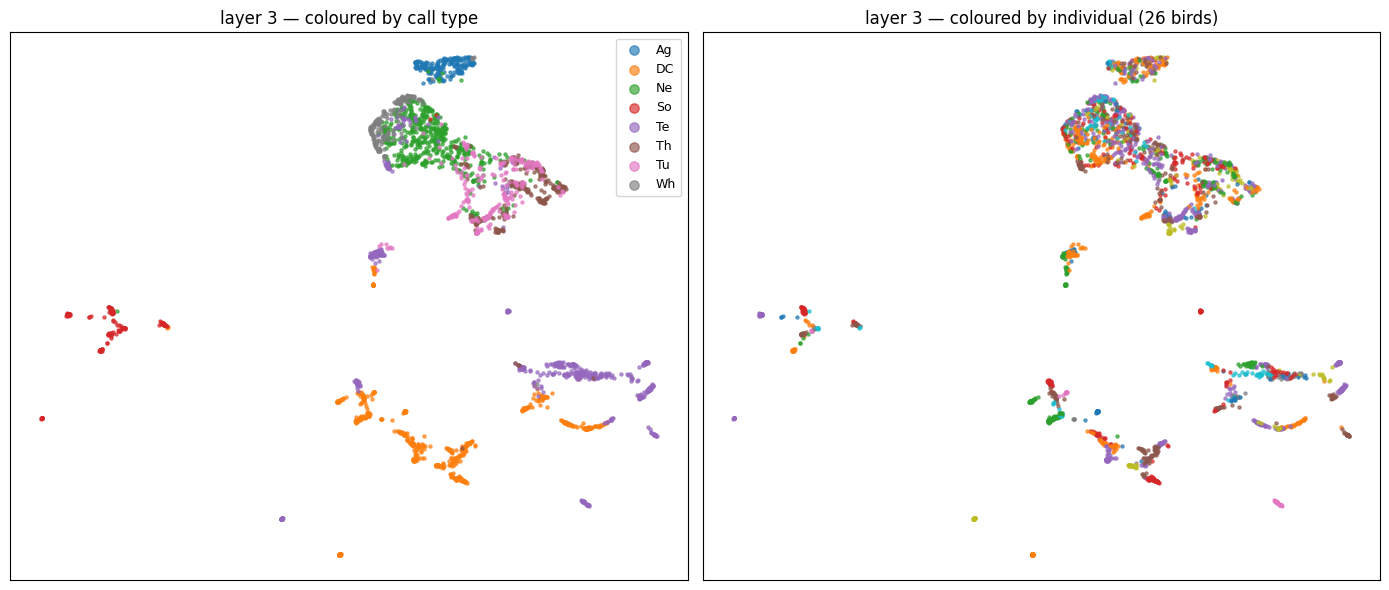

In [13]:
try:
    import umap
    Z = umap.UMAP(n_neighbors=25, min_dist=0.1, metric="cosine", random_state=0).fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for i, ci in enumerate(classes):
        m = y == i
        axes[0].scatter(Z[m, 0], Z[m, 1], s=5, alpha=.65, label=ci)
    axes[0].legend(markerscale=3, fontsize=9)
    axes[0].set_title(f"layer {LAYER} — coloured by call type")
    for b in np.unique(birds):
        m = birds == b
        axes[1].scatter(Z[m, 0], Z[m, 1], s=5, alpha=.65)
    axes[1].set_title(f"layer {LAYER} — coloured by individual ({len(np.unique(birds))} birds)")
    for a in axes: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()
except ImportError:
    print("pip install umap-learn to run this cell")

---

## Using it on your own recordings

```python
model = load_encoder(WEIGHTS)                      # or device="cuda"

emb = embed_file(model, "my_clip.wav")             # (12, 768) — all layers, one forward pass
emb = embed_file(model, "my_clip.wav", layer=0)    # (768,)
frames = embed_frames(model, load_audio("rec.wav"))# (12, T, 768) — keeps the time axis

X = np.stack([embed_file(model, p, layer=3) for p in my_paths])
```

**Which layer:** 0 for detection or segmentation, 3 for call type and clustering. For anything
new, extract all 12 and sweep — they come from one forward pass, so it costs nothing extra.

## Caveats worth carrying

**Pretraining overlap.** The clips evaluated here were part of the ~100 h corpus the model was
pretrained on. Pretraining was label-free, so call-type memorization is impossible — but the
model has heard this audio, so absolute figures may be optimistic relative to a fresh recording
session. Comparisons between layers, models, and baselines are unaffected, since all of them see
exactly the same clips.

**Detection ground truth is constructed, not annotated.** See Result 2. Precision is a lower
bound, and no human has yet verified the background windows.

**Mono downmix.** Channels are averaged. Fine for two mics on one bird, wrong if your channels
are different individuals — pick a channel instead.

**Mean-pooling.** Good for short single calls, throws away temporal structure. Clips here span
0.032–11.705 s (365x), and every embedding is a mean over frames — Song averages ~585 frames,
Tuck ~3. Those are not comparable summaries, which likely explains both duration's strength as a
baseline and Song's trivial separability. For song or anything with internal sequence, use
`embed_frames` and keep the time axis.

## Baselines that have since been run

The three baselines this notebook used to list as "worth trying next" have been run:

| baseline | result |
|---|---|
| **random-init encoder** (same architecture, no pretrained weights) | at the null floor on chick clustering (0.014–0.069 vs null 0.005) — the structure is learned, not architectural |
| **duration alone** | Ward k=9 AMI **0.395** vs HuBERT 0.609. A big free lunch; always report it alongside |
| **log-band spectrogram** | Ward k=9 AMI **0.461**. HuBERT earns +0.148 over it |

## Still worth trying

- Hand-label the detection review bundles to turn lower-bound precision into a real FPR.
- Move detection from window classification to temporal onset/offset detection.
- Frame-level rather than clip-level clustering, to look for sub-call structure.
- A genuinely independent corpus. The clips here are the public Elie & Theunissen release, which
  is also what the model pretrained on, so no held-out set can be carved from it.